In [2]:
import pandas as pd
import numpy as np
import glob
import zipfile
from ast import literal_eval
import tldextract
from collections import Counter
from multiprocessing import Pool
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_allU = pd.read_pickle("all_users.pkl")

In [7]:
df = pd.read_pickle("politicalPols.pkl")

In [8]:
av = df_allU[df_allU.label == "anti-vax"].userid.values
pv = df_allU[df_allU.label == "pro-vax"].userid.values
bv = df_allU[df_allU.label == "both"].userid.values

0.7873364320719446 0.7730748564575558
0.04509118759274329 -1.0344027329234122
0.16568434839554683 -0.761266822130482


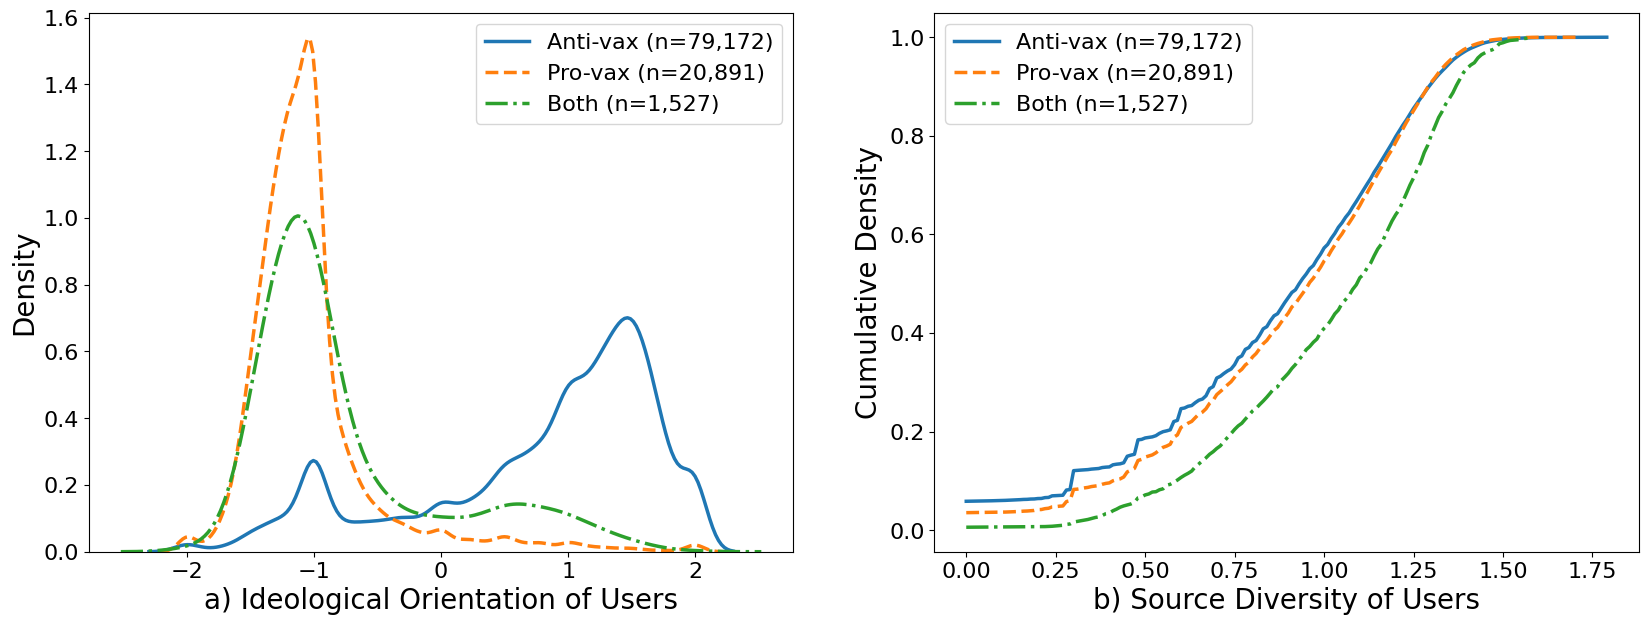

In [30]:
plt.figure(figsize=(20,7))

plt.subplot(1,2,1)

linestyle=["-","--","-."]
titles = ["Anti-vax", "Pro-vax", "Both"]
for i,p in enumerate([av,pv,bv]):
    df_s = df[df.userid.isin(p)]
    sns.kdeplot(df_s.pol_mean, label = titles[i] + " (n={:,})".format(len(df_s)), linestyle=linestyle[i], linewidth=2.5)
    print( (df_s > 0).pol_mean.mean(), df_s.pol_mean.mean() )
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel("Density",fontsize=20)
plt.xlabel("a) Ideological Orientation of Users", fontsize=20)

plt.subplot(1,2,2)
for i,p in enumerate([av,pv,bv]):
    df_s = df[df.userid.isin(p)].copy()

    df_s["ent_rnd"] = df_s.ent.apply(lambda x: np.round(x,2))
    x = df_s.ent_rnd.value_counts().reset_index()
    x.columns = ["entropy", "freq"]
    x["prob"] = x.freq / x.freq.sum()
    x = x.sort_values("entropy")
    x["cumprob"] = np.cumsum( x.prob )
    x,y = x.entropy.values, x.cumprob.values

    plt.plot(x,y, label = titles[i] + " (n={:,})".format(len(df_s)), linestyle=linestyle[i], linewidth=2.5)

plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("b) Source Diversity of Users", fontsize=20)
plt.ylabel("Cumulative Density", fontsize=20)

plt.savefig("figures/ideology_diversity.png", bbox_inches="tight")